**Importação de bibliotecas importantes para o projeto**

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install xgboost

# Configurações de exibição para facilitar a leitura
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

**Carregamento dos dados a partir do .csv**

In [49]:
# 1. CARREGAMENTO DOS DADOS
def load_data(file_path):
    """Carrega o arquivo CSV e exibe informações básicas."""
    df = pd.read_csv(file_path)
    print(f"Dataset carregado com {df.shape[0]} linhas e {df.shape[1]} colunas.")
    return df

df_obesity = pd.read_csv('Dados/Obesity.csv')

**Análise exploratória do dados (incluindo limpeza e preparação)**

In [50]:
# 1. VISÃO GERAL E TIPAGEM
print("--- 1. Estrutura dos Dados ---")
# O info() mostra o total de linhas, colunas, tipos de dados e se há nulos aparentes
print(df_obesity.info())

# 2. ANÁLISE DE VALORES AUSENTES (NULOS)
def check_missing_data(df):
    print("\n--- 2. Análise de Valores Ausentes ---")
    null_counts = df.isnull().sum()
    null_percent = (df.isnull().sum() / len(df)) * 100

    null_df = pd.concat([null_counts, null_percent], axis=1, keys=['Total Nulos', '%'])
    null_df = null_df[null_df['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

    if null_df.empty:
        print("Não existem valores nulos no dataset!")
    else:
        print(null_df)
    return null_df

check_missing_data(df_obesity)

# 3. ANÁLISE DE DUPLICATAS
def check_duplicates(df):
    print("\n--- 3. Análise de Registros Duplicados ---")
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"Foram encontrados {duplicates} registros idênticos.")
    else:
        print("Não existem registros duplicados.")

check_duplicates(df_obesity)

# 4. VALIDAÇÃO DE CONSISTÊNCIA (Baseado no Dicionário)
def validate_ranges(df):
    print("\n--- 4. Verificação de Consistência e 'Ruído' ---")
    # O dicionário diz que FCVC, NCP, CH2O, FAF e TUE são escalas, mas têm decimais (ruído)
    cols_escala = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

    for col in cols_escala:
        if col in df.columns:
            # Verifica se a coluna é float (indicando o ruído mencionado)
            if df[col].dtype == 'float64':
                print(f"Coluna [{col}]: Contém decimais. Necessita arredondamento conforme dicionário.")

            # Verifica os valores mínimos e máximos para ver se respeitam a escala
            print(f"  -> Intervalo de {col}: Min {df[col].min():.2f} | Max {df[col].max():.2f}")

# 5. ANÁLISE DE VARIÁVEIS CATEGÓRICAS
print("\n--- 5. Verificação de Categorias ---")
# Vamos ver se não existem erros de digitação em colunas importantes
for col in ['CAEC', 'CALC', 'MTRANS', 'Obesity']:
    print(f"Valores únicos em {col}: {df_obesity[col].unique().tolist()}")

--- 1. Estrutura dos Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes:

**Identificação e remoção de linhas duplicadas**

In [51]:
# 1. Identificando o total de linhas duplicadas
total_duplicates = df_obesity.duplicated().sum()
print(f"Total de registros exatamente iguais: {total_duplicates}")

# 2. Isolando as linhas duplicadas para inspeção visual
# Usamos keep=False para ver TODAS as instâncias (a original e a cópia)
# Assim podemos comparar se todos os campos são realmente idênticos
df_duplicates = df_obesity[df_obesity.duplicated(keep=False)].sort_values(by=list(df_obesity.columns))

print("\n--- Visualização das Linhas Duplicadas (Amostra) ---")
# Exibindo as primeiras 10 linhas para análise
display(df_duplicates.head(10))

# 3. Verificando a proporção de duplicatas por classe de Obesidade
# Isso ajuda a entender se a duplicidade está concentrada em algum grupo
print("\n--- Distribuição das Duplicatas por Nível de Obesidade ---")
print(df_duplicates['Obesity'].value_counts())

# Removendo as duplicatas e mantendo apenas a primeira ocorrência
df_obesity = df_obesity.drop_duplicates(keep='first').reset_index(drop=True)

print(f"Dataset final após remoção: {df_obesity.shape[0]} linhas.")

# 4. LIMPEZA E TRATAMENTO DE DADOS
def clean_data(df):
    """Executa a limpeza, tratamento de tipos e arredondamentos conforme dicionário."""
    df_clean = df.copy()

    # Verificação de valores nulos
    null_count = df_clean.isnull().sum().sum()
    print(f"Total de valores nulos encontrados: {null_count}")

    # O dicionário especifica que algumas colunas possuem valores decimais que devem ser arredondados
    # para representar categorias inteiras das escalas médicas.
    cols_to_round = {
        'FCVC': 0, # Frequência de consumo de vegetais (escala 1-3)
        'NCP': 0,  # Número de refeições principais (escala 1-4)
        'CH2O': 0, # Consumo diário de água (escala 1-3)
        'FAF': 0,  # Frequência de atividade física (escala 0-3)
        'TUE': 0   # Tempo usando dispositivos eletrônicos (escala 0-2)
    }

    for col, decimals in cols_to_round.items():
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].round(decimals).astype(int)

    # Arredondamento da Idade para facilitar a análise estatística inicial
    df_clean['Age'] = df_clean['Age'].round(0).astype(int)

    # Tratamento de tipos: Converter colunas de texto para categorias
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df_clean[col] = df_clean[col].astype('category')

    print("Limpeza e tratamento de tipos concluídos.")
    return df_clean

df_processed = clean_data(df_obesity)

Total de registros exatamente iguais: 24

--- Visualização das Linhas Duplicadas (Amostra) ---


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
295,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
282,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
523,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
527,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
659,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
663,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight



--- Distribuição das Duplicatas por Nível de Obesidade ---
Obesity
Overweight_Level_I     15
Normal_Weight          10
Insufficient_Weight     8
Name: count, dtype: int64
Dataset final após remoção: 2087 linhas.
Total de valores nulos encontrados: 0
Limpeza e tratamento de tipos concluídos.


**Análise estatístisca descritiva e gráfico de correlação**


--- Estatísticas de Variáveis Numéricas ---


,count,mean,std,min,25%,50%,75%,max
Age,2087.0,24.356493,6.379977,14.00,20.000000,23.000000,26.000000,61.00
Height,2087.0,1.702674,0.093186,1.45,1.630178,1.701584,1.769491,1.98
Weight,2087.0,86.858730,26.190847,39.00,66.000000,83.101100,108.015907,173.00
FCVC,2087.0,2.425970,0.585177,1.00,2.000000,2.000000,3.000000,3.00
NCP,2087.0,2.703402,0.797108,1.00,3.000000,3.000000,3.000000,4.00
CH2O,2087.0,2.011500,0.685322,1.00,2.000000,2.000000,2.000000,3.00
FAF,2087.0,1.009104,0.898712,0.00,0.000000,1.000000,2.000000,3.00
TUE,2087.0,0.669861,0.673970,0.00,0.000000,1.000000,1.000000,2.00



--- Frequência da Variável Alvo (Obesity) ---
Obesity
Obesity_Type_I         16.818400
Obesity_Type_III       15.524677
Obesity_Type_II        14.230954
Overweight_Level_II    13.895544
Normal_Weight          13.512218
Overweight_Level_I     13.224724
Insufficient_Weight    12.793483
Name: proportion, dtype: float64


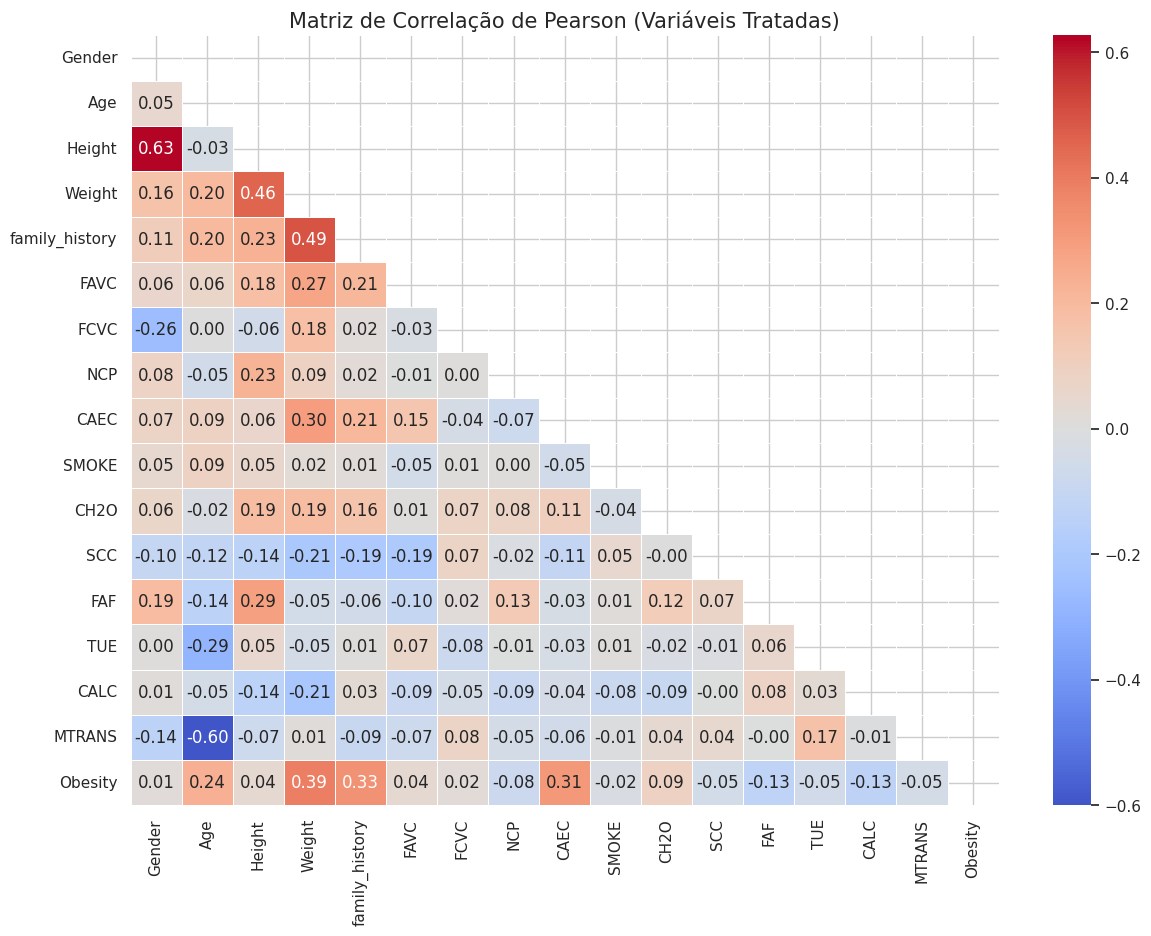

In [52]:
# 1. ANÁLISE ESTATÍSTICA DESCRITIVA
def perform_statistical_analysis(df):
    """Gera estatísticas descritivas para variáveis numéricas e categóricas."""
    print("\n--- Estatísticas de Variáveis Numéricas ---")
    display(df.describe().T)

    print("\n--- Frequência da Variável Alvo (Obesity) ---")
    print(df['Obesity'].value_counts(normalize=True) * 100)

perform_statistical_analysis(df_processed)

# 2. ANÁLISE DE CORRELAÇÃO
def plot_correlation_matrix(df):
    """
    Calcula e plota a matriz de correlação.
    """
    df_corr = df.copy()

    # Codificação temporária para variáveis categóricas para permitir o cálculo da correlação
    for col in df_corr.select_dtypes(include=['category']).columns:
        df_corr[col] = df_corr[col].cat.codes

    plt.figure(figsize=(14, 10))
    correlation_matrix = df_corr.corr()

    # Máscara para ocultar a parte superior da matriz (espelhada)
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    sns.heatmap(correlation_matrix,
                mask=mask,
                annot=True,
                fmt=".2f",
                cmap='coolwarm',
                center=0,
                linewidths=.5)

    plt.title('Matriz de Correlação de Pearson (Variáveis Tratadas)', fontsize=15)
    plt.show()

plot_correlation_matrix(df_processed)

**Feature Engeneering**

In [53]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def feature_engineering(df):
    """
    Prepara os dados para os modelos da forma mais simples e direta.
    """
    df_ml = df.copy()

    # 1. VARIÁVEIS ORDINAIS (Ordem lógica de intensidade)
    mapa_frequencia = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}

    df_ml['CAEC'] = df_ml['CAEC'].map(mapa_frequencia).astype(int)
    df_ml['CALC'] = df_ml['CALC'].map(mapa_frequencia).astype(int)

    # 2. VARIÁVEIS BINÁRIAS (Transformação para 0 e 1)
    le = LabelEncoder()
    colunas_binarias = ['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC']

    for col in colunas_binarias:
        df_ml[col] = le.fit_transform(df_ml[col])

    # 3. VARIÁVEIS NOMINAIS (Criação de colunas separadas para transporte)
    df_ml = pd.get_dummies(df_ml, columns=['MTRANS'], prefix='Transp')

    # 4. VARIÁVEL ALVO (Correção da Escala Médica)
    mapa_obesidade = {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
    df_ml['Obesity'] = df_ml['Obesity'].map(mapa_obesidade)

    print("✅ Feature Engineering concluída com sucesso!")
    print(f"Total de colunas geradas: {df_ml.shape[1]}")

    return df_ml

# Utilizando o dataframe processado da sua etapa de limpeza
df_ready = feature_engineering(df_processed)

# Visualiza as primeiras linhas
display(df_ready.head())

✅ Feature Engineering concluída com sucesso!
Total de colunas geradas: 21


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,Obesity,Transp_Automobile,Transp_Bike,Transp_Motorbike,Transp_Public_Transportation,Transp_Walking
0,0,21,1.62,64.0,1,0,2,3,1,0,2,0,0,1,0,1,False,False,False,True,False
1,0,21,1.52,56.0,1,0,3,3,1,1,3,1,3,0,1,1,False,False,False,True,False
2,1,23,1.80,77.0,1,0,2,3,1,0,2,0,2,1,2,1,False,False,False,True,False
3,1,27,1.80,87.0,0,0,3,3,1,0,2,0,2,0,2,2,False,False,False,False,True
4,1,22,1.78,89.8,0,0,2,1,1,0,2,0,0,0,1,3,False,False,False,True,False


**Remoção de variáveis que não farão parte do modelo e split de treino e teste**

In [54]:
from sklearn.model_selection import train_test_split

# 1. DEFINIÇÃO DAS VARIÁVEIS
# O X contém os dados que o modelo vai usar para aprender.
# Removidos 'Obesity' (pois é a resposta) e 'Height' e 'Weight' (regra de negócio, para não ser possível calcular o IMC) e Gender.
X = df_ready.drop(columns=['Obesity', 'Height', 'Weight', 'Gender'])

# O y contém apenas a resposta correta (o diagnóstico de 0 a 6).
y = df_ready['Obesity']

# 2. SEPARAÇÃO EM TREINO E TESTE
# test_size=0.2 reserva 20% dos dados para avaliar a precisão do modelo.
# random_state=42 garante que a divisão seja sempre idêntica em todas as execuções.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. VALIDAÇÃO DA SEPARAÇÃO
print("✅ Separação dos dados concluída com sucesso!")
print(f"Linhas reservadas para treino: {X_train.shape[0]}")
print(f"Linhas reservadas para teste: {X_test.shape[0]}")
print(f"Colunas ativas no modelo: {len(X_train.columns)}")

✅ Separação dos dados concluída com sucesso!
Linhas reservadas para treino: 1669
Linhas reservadas para teste: 418
Colunas ativas no modelo: 17


**Treinamento de 4 modelos de Machine Learning, para comparação dos resultados e eleger o melhor**

**Random Forest**

In [55]:
# ==========================================
# MODELO 1: RANDOM FOREST
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- TREINAMENTO: RANDOM FOREST ---")

# Treinamento
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
modelo_rf.fit(X_train, y_train)

# Predição e Acurácia
y_pred_rf = modelo_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

nomes_classes = ['Abaixo do Peso', 'Peso Normal', 'Sobrepeso I', 'Sobrepeso II', 'Obesidade I', 'Obesidade II', 'Obesidade III']

print(f"Acurácia Random Forest: {acc_rf:.2%}\n")
print(classification_report(y_test, y_pred_rf, target_names=nomes_classes))

--- TREINAMENTO: RANDOM FOREST ---
Acurácia Random Forest: 74.88%

                precision    recall  f1-score   support

Abaixo do Peso       0.81      0.81      0.81        59
   Peso Normal       0.63      0.48      0.54        61
   Sobrepeso I       0.73      0.55      0.62        55
  Sobrepeso II       0.68      0.65      0.67        49
   Obesidade I       0.68      0.76      0.72        70
  Obesidade II       0.81      0.95      0.88        64
 Obesidade III       0.83      1.00      0.91        60

      accuracy                           0.75       418
     macro avg       0.74      0.74      0.74       418
  weighted avg       0.74      0.75      0.74       418



**Gradient Boost**

In [56]:
# ==========================================
# MODELO 2: GRADIENT BOOSTING
# ==========================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- TREINAMENTO: GRADIENT BOOSTING ---")

# Treinamento
modelo_gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo_gb.fit(X_train, y_train)

# Predição e Acurácia
y_pred_gb = modelo_gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

print(f"Acurácia Gradient Boosting: {acc_gb:.2%}\n")
print(classification_report(y_test, y_pred_gb, target_names=nomes_classes))

--- TREINAMENTO: GRADIENT BOOSTING ---
Acurácia Gradient Boosting: 76.08%

                precision    recall  f1-score   support

Abaixo do Peso       0.90      0.78      0.84        59
   Peso Normal       0.58      0.49      0.53        61
   Sobrepeso I       0.73      0.67      0.70        55
  Sobrepeso II       0.63      0.76      0.69        49
   Obesidade I       0.67      0.74      0.70        70
  Obesidade II       0.89      0.88      0.88        64
 Obesidade III       0.94      1.00      0.97        60

      accuracy                           0.76       418
     macro avg       0.76      0.76      0.76       418
  weighted avg       0.76      0.76      0.76       418



**XGBoost**

In [57]:
# ==========================================
# MODELO 3: XGBOOST
# ==========================================
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- TREINAMENTO: XGBOOST ---")

# Treinamento
modelo_xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
modelo_xgb.fit(X_train, y_train)

# Predição e Acurácia
y_pred_xgb = modelo_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"Acurácia XGBoost: {acc_xgb:.2%}\n")
print(classification_report(y_test, y_pred_xgb, target_names=nomes_classes))

--- TREINAMENTO: XGBOOST ---
Acurácia XGBoost: 75.60%

                precision    recall  f1-score   support

Abaixo do Peso       0.89      0.80      0.84        59
   Peso Normal       0.58      0.48      0.52        61
   Sobrepeso I       0.72      0.65      0.69        55
  Sobrepeso II       0.63      0.65      0.64        49
   Obesidade I       0.72      0.74      0.73        70
  Obesidade II       0.79      0.94      0.86        64
 Obesidade III       0.91      1.00      0.95        60

      accuracy                           0.76       418
     macro avg       0.75      0.75      0.75       418
  weighted avg       0.75      0.76      0.75       418



**LightGBM**

In [58]:
# ==========================================
# MODELO 4: LIGHTGBM (Versão Silenciosa)
# ==========================================
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report
import re

print("--- TREINAMENTO: LIGHTGBM ---")

# 1. TRATAMENTO DE NOMES DE COLUNAS (Para evitar o aviso de whitespace)
# O LightGBM exige nomes de colunas limpos (sem espaços ou caracteres especiais)
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean.columns = [re.sub(r'[^\w\s]', '', col).replace(' ', '_') for col in X_train_clean.columns]
X_test_clean.columns = [re.sub(r'[^\w\s]', '', col).replace(' ', '_') for col in X_test_clean.columns]

# 2. TREINAMENTO DO MODELO (Com verbose=-1 para silenciar as mensagens [Info])
modelo_lgbm = lgb.LGBMClassifier(
    n_estimators=150,
    max_depth=7,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
modelo_lgbm.fit(X_train_clean, y_train)

# 3. PREDIÇÃO E ACURÁCIA
y_pred_lgbm = modelo_lgbm.predict(X_test_clean)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)

nomes_classes = ['Abaixo do Peso', 'Peso Normal', 'Sobrepeso I', 'Sobrepeso II', 'Obesidade I', 'Obesidade II', 'Obesidade III']

print(f"Acurácia LightGBM: {acc_lgbm:.2%}\n")
print(classification_report(y_test, y_pred_lgbm, target_names=nomes_classes))

--- TREINAMENTO: LIGHTGBM ---
Acurácia LightGBM: 77.03%

                precision    recall  f1-score   support

Abaixo do Peso       0.92      0.78      0.84        59
   Peso Normal       0.57      0.52      0.55        61
   Sobrepeso I       0.76      0.71      0.74        55
  Sobrepeso II       0.63      0.65      0.64        49
   Obesidade I       0.71      0.79      0.74        70
  Obesidade II       0.84      0.91      0.87        64
 Obesidade III       0.95      1.00      0.98        60

      accuracy                           0.77       418
     macro avg       0.77      0.77      0.77       418
  weighted avg       0.77      0.77      0.77       418



**Comparação dos modelos**

/tmp/ipykernel_5572/3347723717.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


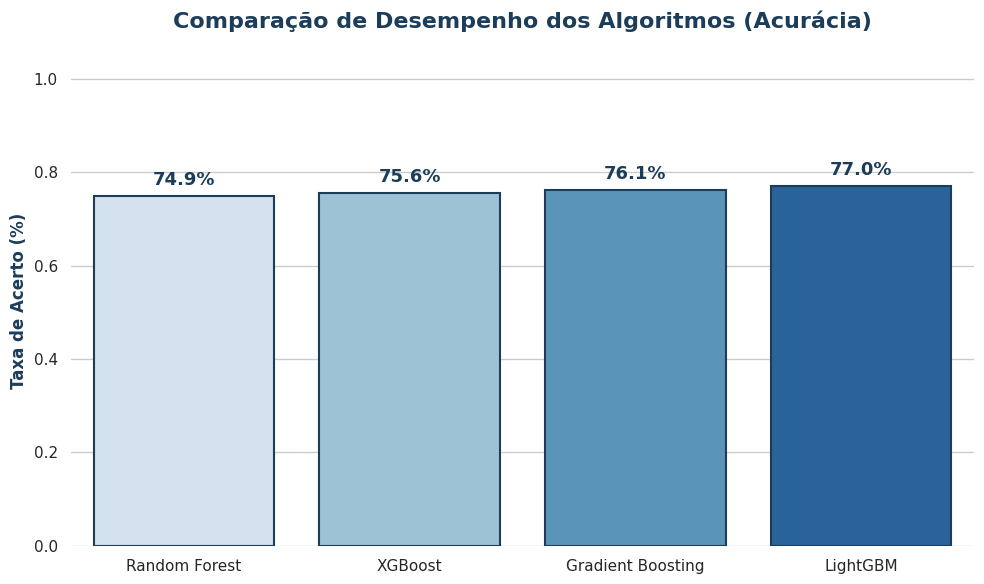

🏆 O modelo vencedor foi o **LightGBM** com 77.03% de acurácia!
✅ Ficheiro 'modelo_v2_techchallenge.pkl' gerado e pronto para o Streamlit.


In [59]:
# ==========================================
# COMPARAÇÃO VISUAL E EXPORTAÇÃO DO MELHOR MODELO
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Organizando os resultados
modelos_nomes = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']
acuracias = [acc_rf, acc_gb, acc_xgb, acc_lgbm]
modelos_obj = [modelo_rf, modelo_gb, modelo_xgb, modelo_lgbm]

# Ordenar do menor para o maior para criar um efeito de "escada" visual
dados_grafico = pd.DataFrame({'Modelo': modelos_nomes, 'Acurácia': acuracias})
dados_grafico = dados_grafico.sort_values(by='Acurácia', ascending=True)

# 2. Configurando o Gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras com paleta degradê de azuis
ax = sns.barplot(
    x='Modelo',
    y='Acurácia',
    data=dados_grafico,
    palette="Blues",
    edgecolor="#1c3d5a",
    linewidth=1.5
)

# Títulos e Eixos
plt.title('Comparação de Desempenho dos Algoritmos (Acurácia)', fontsize=16, fontweight='bold', color='#1c3d5a', pad=20)
plt.ylabel('Taxa de Acerto (%)', fontsize=12, fontweight='bold', color='#1c3d5a')
plt.xlabel('', fontsize=12) # Esconde o nome do eixo X para ficar mais limpo
plt.ylim(0, 1.05)

# 3. Adicionando os valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=13, fontweight='bold', color='#1c3d5a',
                xytext=(0, 5), textcoords='offset points')

# Remove as bordas laterais e superior para aspecto mais moderno
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 4. Salvando o vencedor
melhor_modelo_nome = dados_grafico.iloc[-1]['Modelo']
indice_vencedor = modelos_nomes.index(melhor_modelo_nome)
joblib.dump(modelos_obj[indice_vencedor], 'Modelo ML/modelo_v2_techchallenge.pkl')

print("="*65)
print(f"🏆 O modelo vencedor foi o **{melhor_modelo_nome}** com {dados_grafico.iloc[-1]['Acurácia']:.2%} de acurácia!")
print("✅ Ficheiro 'modelo_v2_techchallenge.pkl' gerado e pronto para o Streamlit.")
print("="*65)

**Gera o app.py com a aplicação e utilização da base e modelo**

In [60]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import time
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit.components.v1 as components
from sklearn.preprocessing import LabelEncoder

# 1. CONFIGURAÇÃO DA PÁGINA
st.set_page_config(page_title="Diagnóstico de Obesidade", layout="wide")

st.markdown("""
    <style>
        .block-container {
            padding-top: 3rem;
            padding-bottom: 1rem;
        }
    </style>
""", unsafe_allow_html=True)

# 2. CARREGAMENTO DE MODELOS E DADOS
@st.cache_resource
def carregar_modelos():
    # Caminho atualizado para a pasta "Modelo ML"
    return joblib.load('Modelo ML/modelo_v2_techchallenge.pkl')

@st.cache_data
def carregar_dados():
    # Caminho atualizado para a pasta "Dados"
    return pd.read_csv('Dados/Obesity.csv')

modelo = carregar_modelos()
df_raw = carregar_dados()

# Dicionários de tradução e ordenação
traducao_diagnostico = {
    'Insufficient_Weight': 'Abaixo do Peso',
    'Normal_Weight': 'Peso Normal',
    'Overweight_Level_I': 'Sobrepeso Grau I',
    'Overweight_Level_II': 'Sobrepeso Grau II',
    'Obesity_Type_I': 'Obesidade Tipo I',
    'Obesity_Type_II': 'Obesidade Tipo II',
    'Obesity_Type_III': 'Obesidade Tipo III'
}

ordem_categorias = [
    'Abaixo do Peso', 'Peso Normal', 'Sobrepeso Grau I',
    'Sobrepeso Grau II', 'Obesidade Tipo I', 'Obesidade Tipo II', 'Obesidade Tipo III'
]

# 3. NAVEGAÇÃO POR ABAS NO TOPO
tab1, tab2 = st.tabs(["🩺 Diagnóstico Inteligente", "📊 Dashboards Analíticos"])

# ==========================================
# ABA 1: DIAGNÓSTICO
# ==========================================
with tab1:
    st.title("🏥 Sistema de Prevenção e Diagnóstico de Obesidade")
    st.markdown("Preencha os hábitos do paciente para o modelo prever o risco comportamental.")

    with st.form("form_diagnostico"):
        col1, col2, col3 = st.columns(3)

        with col1:
            st.header("Dados Biológicos")
            genero_pt = st.selectbox("Sexo Biológico (Apenas Informativo)", ["Feminino", "Masculino"])
            idade = st.number_input("Idade", min_value=10, max_value=100, value=25)

            st.markdown("---")
            st.markdown("**Dados Físicos (Informativo)**")
            altura = st.number_input("Altura (m)", min_value=1.40, max_value=2.20, value=1.70, format="%.2f")
            peso = st.number_input("Peso (kg)", min_value=30.0, max_value=250.0, value=70.0, format="%.1f")
            imc = peso / (altura ** 2)
            st.info(f"📊 IMC Calculado: {imc:.1f}")

        with col2:
            st.header("Histórico e Dieta")
            hist_familiar = st.selectbox("Histórico Familiar de Sobrepeso?", ["Sim", "Não"])
            comida_calorica = st.selectbox("Consome alimentos calóricos?", ["Sim", "Não"])
            vegetais = st.slider("Frequência de vegetais (1-3)", 1, 3, 2)
            refeicoes = st.slider("Refeições principais por dia", 1, 4, 3)
            lanches = st.selectbox("Lanches entre refeições?", ["Não", "Às vezes", "Frequentemente", "Sempre"])

        with col3:
            st.header("Estilo de Vida")
            agua = st.slider("Consumo de água (L/dia)", 1, 3, 2)
            exercicio = st.slider("Atividade física (dias/semana)", 0, 3, 1)
            telas = st.slider("Tempo em telas (0-2)", 0, 2, 1)
            alcool = st.selectbox("Consumo de álcool?", ["Não", "Às vezes", "Frequentemente", "Sempre"])
            transporte = st.selectbox("Meio de transporte", ["Automóvel", "Moto", "Bicicleta", "Transporte Público", "A pé"])
            monitora_calorias = st.selectbox("Monitora calorias?", ["Sim", "Não"])
            fumante = st.selectbox("Fumante?", ["Sim", "Não"])

        st.markdown("<br>", unsafe_allow_html=True)
        btn_analisar = st.form_submit_button("🔮 Gerar Diagnóstico Inteligente", type="primary", use_container_width=True)

    if btn_analisar:
        mapa_sim_nao = {"Não": 0, "Sim": 1}
        mapa_freq = {"Não": 0, "Às vezes": 1, "Frequentemente": 2, "Sempre": 3}
        mapa_transporte = {"Automóvel": "Automobile", "Moto": "Motorbike", "Bicicleta": "Bike", "Transporte Público": "Public_Transportation", "A pé": "Walking"}

        dados_paciente = {col: 0 for col in modelo.feature_names_in_}

        if 'Age' in dados_paciente: dados_paciente['Age'] = idade
        if 'family_history' in dados_paciente: dados_paciente['family_history'] = mapa_sim_nao[hist_familiar]
        if 'FAVC' in dados_paciente: dados_paciente['FAVC'] = mapa_sim_nao[comida_calorica]
        if 'FCVC' in dados_paciente: dados_paciente['FCVC'] = vegetais
        if 'NCP' in dados_paciente: dados_paciente['NCP'] = refeicoes
        if 'CAEC' in dados_paciente: dados_paciente['CAEC'] = mapa_freq[lanches]
        if 'CH2O' in dados_paciente: dados_paciente['CH2O'] = agua
        if 'FAF' in dados_paciente: dados_paciente['FAF'] = exercicio
        if 'TUE' in dados_paciente: dados_paciente['TUE'] = telas
        if 'CALC' in dados_paciente: dados_paciente['CALC'] = mapa_freq[alcool]
        if 'SCC' in dados_paciente: dados_paciente['SCC'] = mapa_sim_nao[monitora_calorias]
        if 'SMOKE' in dados_paciente: dados_paciente['SMOKE'] = mapa_sim_nao[fumante]

        col_transp = f"Transp_{mapa_transporte[transporte]}"
        if col_transp in dados_paciente:
            dados_paciente[col_transp] = 1

        df_modelo = pd.DataFrame([dados_paciente])
        df_modelo = df_modelo[modelo.feature_names_in_]

        pred_raw = modelo.predict(df_modelo)[0]
        classes_raw = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

        try:
            indice = int(pred_raw)
            resultado_en = classes_raw[indice]
        except (ValueError, TypeError):
            resultado_en = str(pred_raw)

        resultado_pt = traducao_diagnostico.get(resultado_en, resultado_en)

        st.markdown("---")
        st.markdown("<div id='ancora-resultado'></div>", unsafe_allow_html=True)

        st.subheader("📋 Resultado da IA")
        if "Obesity" in resultado_en:
            st.error(f"### Risco Comportamental: **{resultado_pt}**")
            st.markdown("⚠️ **Alerta:** Os hábitos indicam forte tendência à obesidade. Recomenda-se acompanhamento nutricional.")
        elif "Overweight" in resultado_en:
            st.warning(f"### Risco Comportamental: **{resultado_pt}**")
            st.markdown("🧡 **Aviso:** Paciente com hábitos que levam ao sobrepeso. Sugere-se ajuste no estilo de vida.")
        else:
            st.success(f"### Risco Comportamental: **{resultado_pt}**")
            st.markdown("✅ **Status:** Os hábitos atuais do paciente são condizentes com a manutenção de um peso saudável.")

        st.markdown("---")
        st.markdown("**🔍 Nível de Confiança do Modelo (Probabilidades):**")

        probabilidades = modelo.predict_proba(df_modelo)[0]

        df_probs = pd.DataFrame({
            'Diagnóstico': [traducao_diagnostico.get(c, c) for c in classes_raw],
            'Probabilidade (%)': probabilidades * 100
        }).sort_values(by='Probabilidade (%)', ascending=True)

        fig = px.bar(
            df_probs,
            x='Probabilidade (%)',
            y='Diagnóstico',
            orientation='h',
            text_auto='.1f',
            color='Probabilidade (%)',
            color_continuous_scale='Blues'
        )
        fig.update_layout(
            xaxis_title="Probabilidade (%)",
            yaxis_title="",
            showlegend=False,
            height=400,
            margin=dict(l=0, r=0, t=30, b=0)
        )
        st.plotly_chart(fig, use_container_width=True)

        timestamp_atual = time.time()
        components.html(
            f"""
            <script>
                // Execução {timestamp_atual}
                window.parent.document.getElementById('ancora-resultado').scrollIntoView({{behavior: 'smooth'}});
            </script>
            """,
            height=0
        )

# ==========================================
# ABA 2: DASHBOARDS
# ==========================================
with tab2:
    st.title("📊 Dashboards Analíticos")

    opcoes_graficos = [
        "Distribuição Geral",
        "Obesidade por Gênero",
        "Impacto do Histórico Familiar",
        "Matriz de Correlação",
        "Principais Fatores (ML)"
    ]
    opcao = st.radio("Escolha a visão:", opcoes_graficos, horizontal=True)

    df_plot = df_raw.copy()

    if opcao == "Distribuição Geral":
        df_plot['Obesity'] = df_plot['Obesity'].map(traducao_diagnostico)
        df_pie = df_plot['Obesity'].value_counts().reset_index()
        df_pie.columns = ['Obesity', 'count']
        fig_dash = px.pie(
            df_pie,
            names='Obesity',
            values='count',
            hole=0.4,
            color_discrete_sequence=px.colors.sequential.Blues_r,
            title="Distribuição das Categorias de Peso na Base Original"
        )
        st.plotly_chart(fig_dash, use_container_width=True)

    elif opcao == "Obesidade por Gênero":
        df_plot['Obesity'] = df_plot['Obesity'].map(traducao_diagnostico)
        df_plot['Gender'] = df_plot['Gender'].map({'Female': 'Feminino', 'Male': 'Masculino'})

        fig_dash = px.histogram(
            df_plot,
            x='Obesity',
            color='Gender',
            barmode='stack',
            color_discrete_map={'Feminino': '#9BB7D4', 'Masculino': '#2C4F73'},
            title="Distribuição de Categorias de Peso por Sexo Biológico"
        )
        fig_dash.update_layout(
            xaxis_title="Categoria de Peso",
            yaxis_title="Quantidade de Pacientes",
            legend_title="Gênero",
            xaxis={'categoryorder':'array', 'categoryarray': ordem_categorias}
        )
        st.plotly_chart(fig_dash, use_container_width=True)

    elif opcao == "Impacto do Histórico Familiar":
        df_plot['Obesity'] = df_plot['Obesity'].map(traducao_diagnostico)
        df_plot['family_history'] = df_plot['family_history'].map({'yes': 'Sim', 'no': 'Não'})

        fig_dash = px.histogram(
            df_plot,
            x='Obesity',
            color='family_history',
            barmode='stack',
            color_discrete_map={'Sim': '#2C4F73', 'Não': '#9BB7D4'},
            title="A Influência do Histórico Familiar na Obesidade"
        )
        fig_dash.update_layout(
            xaxis_title="Categoria de Peso",
            yaxis_title="Quantidade de Pacientes",
            legend_title="Histórico Familiar?",
            xaxis={'categoryorder':'array', 'categoryarray': ordem_categorias}
        )
        st.plotly_chart(fig_dash, use_container_width=True)

    elif opcao == "Matriz de Correlação":
        st.markdown("### Matriz de Correlação de Pearson")
        st.markdown("Mostra a correlação matemática direta entre todas as variáveis do conjunto de dados.")

        df_corr = df_plot.copy()

        # Dicionário para traduzir as colunas do dataset para Português
        mapa_colunas_pt = {
            'Gender': 'Gênero',
            'Age': 'Idade',
            'Height': 'Altura',
            'Weight': 'Peso',
            'family_history': 'Hist. Familiar',
            'FAVC': 'Comida Calórica',
            'FCVC': 'Consumo Vegetais',
            'NCP': 'Refeições/Dia',
            'CAEC': 'Lanches',
            'SMOKE': 'Fumante',
            'CH2O': 'Água/Dia',
            'SCC': 'Monitora Calorias',
            'FAF': 'Ativ. Física',
            'TUE': 'Tempo Tela',
            'CALC': 'Álcool',
            'MTRANS': 'Transporte',
            'Obesity': 'Obesidade'
        }

        # Renomeia as colunas antes de calcular a correlação
        df_corr = df_corr.rename(columns=mapa_colunas_pt)

        le = LabelEncoder()

        # CORREÇÃO: Seleciona todas as colunas não numéricas, independente da versão do Pandas
        colunas_categoricas = df_corr.select_dtypes(exclude=['number']).columns
        for col in colunas_categoricas:
            df_corr[col] = le.fit_transform(df_corr[col])

        corr = df_corr.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))

        fig_corr, ax_corr = plt.subplots(figsize=(12, 8))
        sns.heatmap(
            corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmax=0.6,
            vmin=-0.6,
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8},
            ax=ax_corr
        )
        ax_corr.set_title("Matriz de Correlação (Variáveis Tratadas)", fontsize=16)
        st.pyplot(fig_corr)

    elif opcao == "Principais Fatores (ML)":
        st.markdown("### Principais Fatores Comportamentais que Levam à Obesidade")
        st.markdown("Ranking de importância das variáveis baseada nas árvores de decisão do modelo em produção.")

        importancias = modelo.feature_importances_
        features = modelo.feature_names_in_

        mapa_features_pt = {
            'Age': 'Idade',
            'family_history': 'Hist. Familiar',
            'FAVC': 'Comida Calórica',
            'FCVC': 'Consumo Vegetais',
            'NCP': 'Refeições/Dia',
            'CAEC': 'Lanches',
            'SMOKE': 'Fumante',
            'CH2O': 'Água/Dia',
            'SCC': 'Monitora Calorias',
            'CALC': 'Álcool',
            'FAF': 'Ativ. Física',
            'TUE': 'Tempo Tela',
            'Transp_Automobile': 'Transp. Carro',
            'Transp_Bike': 'Transp. Bicicleta',
            'Transp_Motorbike': 'Transp. Moto',
            'Transp_Public_Transportation': 'Transp. Público',
            'Transp_Walking': 'A Pé'
        }

        df_importancia = pd.DataFrame({
            'Feature Original': features,
            'Importância': importancias
        })

        df_importancia['Fator'] = df_importancia['Feature Original'].map(mapa_features_pt).fillna(df_importancia['Feature Original'])
        df_importancia = df_importancia.sort_values(by='Importância', ascending=True)

        fig_imp = px.bar(
            df_importancia,
            x='Importância',
            y='Fator',
            orientation='h',
            color='Importância',
            color_continuous_scale='inferno'
        )
        fig_imp.update_layout(
            xaxis_title="Nível de Importância",
            yaxis_title="",
            showlegend=False,
            height=600,
            margin=dict(l=0, r=0, t=30, b=0)
        )
        st.plotly_chart(fig_imp, use_container_width=True)

Overwriting app.py


**Código para subir o streamlit no localhost**

In [61]:
import os
import time
from google.colab import output

print("1. Forçando a instalação do Streamlit...")
os.system('pip install streamlit -q')

print("2. Derrubando processos antigos travados...")
os.system('pkill -f streamlit')

# Verifica se a instalação realmente funcionou
stream_check = os.popen('streamlit --version').read().strip()
if not stream_check:
    print("❌ ERRO CRÍTICO: O Colab está bloqueando a instalação do Streamlit. Reinicie o ambiente (Ambiente de Execução > Reiniciar sessão).")
else:
    print(f"✅ Sucesso: {stream_check} instalado.")

    print("3. Iniciando o servidor de Diagnóstico...")
    # Roda o Streamlit com as portas abertas
    os.system('streamlit run app.py --server.address=0.0.0.0 --server.port=8501 --server.enableCORS=false --server.enableXsrfProtection=false &> logs.txt &')

    # Dá 5 segundos para o servidor subir completamente
    time.sleep(5)

    print("\n--- 4. LOGS DO SISTEMA ---")
    os.system('cat logs.txt')

    print("\n--- 5. LINK DE ACESSO ---")
    print("Clique no link gerado abaixo. (Se a tela ficar branca por alguns segundos, aguarde o carregamento).")
    output.serve_kernel_port_as_window(8501)

1. Forçando a instalação do Streamlit...
2. Derrubando processos antigos travados...
✅ Sucesso: Streamlit, version 1.58.0 instalado.
3. Iniciando o servidor de Diagnóstico...

--- 4. LOGS DO SISTEMA ---

--- 5. LINK DE ACESSO ---
Clique no link gerado abaixo. (Se a tela ficar branca por alguns segundos, aguarde o carregamento).
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>